In [1]:
import pandas as pd

# Load datasets
transaction = pd.read_csv(r"C:\Users\User\BigData\Datasets\train_transaction.csv")
identity = pd.read_csv(r"C:\Users\User\BigData\Datasets\train_identity.csv")

# Merge
df = transaction.merge(identity, on='TransactionID', how='left')

df.shape

(590540, 434)

In [2]:
# Basic data understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [3]:
# Missing value analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.head(20)

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_03    524216
id_04    524216
D6       517353
id_33    517251
id_10    515614
dtype: int64

In [4]:
# Drop useless column
threshold = len(df) * 0.7  # 70% missing

df = df.dropna(thresh=threshold, axis=1)

df.shape

(590540, 202)

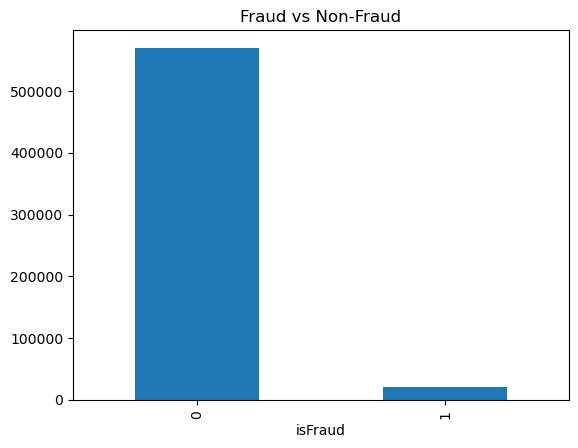

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [5]:
import matplotlib.pyplot as plt

df['isFraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud")
plt.show()

df['isFraud'].value_counts(normalize=True)

In [6]:
# correlation
corr = df.corr(numeric_only=True)

# Correlation with target
corr_target = corr['isFraud'].abs().sort_values(ascending=False)

corr_target.head(20)

isFraud    1.000000
V45        0.281832
V44        0.260376
V86        0.251828
V87        0.251737
V52        0.239469
V51        0.223191
V40        0.212442
V39        0.203097
V38        0.199005
V43        0.198274
V79        0.194141
V42        0.189428
V94        0.188407
V74        0.185915
V33        0.183486
V17        0.182673
V18        0.182550
V81        0.182377
V93        0.180983
Name: isFraud, dtype: float64

In [7]:
# Select top features
top_features = corr_target.head(20).index.tolist()

df = df[top_features]

df.shape

(590540, 20)

In [20]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [10]:
df.dtypes

isFraud      int64
V45        float64
V44        float64
V86        float64
V87        float64
V52        float64
V51        float64
V40        float64
V39        float64
V38        float64
V43        float64
V79        float64
V42        float64
V94        float64
V74        float64
V33        float64
V17        float64
V18        float64
V81        float64
V93        float64
dtype: object

In [11]:
# Split Data
from sklearn.model_selection import train_test_split

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
# Check NaN count
X_train.isnull().sum().sum()

np.int64(1890919)

In [14]:
# Fix missing value
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [15]:
X_train.isnull().sum().sum()

np.int64(0)

In [17]:
# Apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [18]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
# Evaluate model
from sklearn.metrics import classification_report

y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

print("Logistic Regression:\n", classification_report(y_test, y_pred1))
print("Random Forest:\n", classification_report(y_test, y_pred2))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91    113975
           1       0.09      0.44      0.16      4133

    accuracy                           0.83    118108
   macro avg       0.54      0.64      0.53    118108
weighted avg       0.95      0.83      0.88    118108

Random Forest:
               precision    recall  f1-score   support

           0       0.98      0.89      0.93    113975
           1       0.12      0.43      0.19      4133

    accuracy                           0.87    118108
   macro avg       0.55      0.66      0.56    118108
weighted avg       0.95      0.87      0.91    118108



<Axes: >

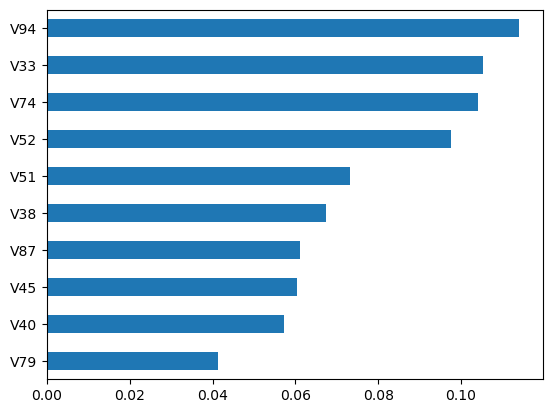

In [23]:
import pandas as pd

importance = model2.feature_importances_
feat_importance = pd.Series(importance, index=X.columns)

feat_importance.sort_values().tail(10).plot(kind='barh')

In [24]:
# Adjust decision threshold
y_prob = model2.predict_proba(X_test)[:,1]

# Lower threshold
y_pred_adjusted = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.98      0.05      0.09    113975
           1       0.04      0.97      0.07      4133

    accuracy                           0.08    118108
   macro avg       0.51      0.51      0.08    118108
weighted avg       0.94      0.08      0.09    118108



In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# NEURAL NETWORK MODEL

print("=" * 50)
print("TRAINING NEURAL NETWORK")
print("=" * 50)

# Create the neural network
nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),    # Two hidden layers: 100 neurons, then 50 neurons
    activation='relu',                # Activation function (helps learn non-linear patterns)
    solver='adam',                    # Optimization algorithm 
    max_iter=500,                     
    random_state=42,                
    early_stopping=True,             
    validation_fraction=0.1,          # Use 10% of training data for validation
    verbose=True                      # Show training progress
)

# Train the model
nn_model.fit(X_train_res, y_train_res)

print("\n✅ Neural Network training complete!")

In [ ]:
# Check what variables are defined
print("Variables in memory:")
print("-" * 30)
try:
    print(f"df shape: {df.shape}")
except:
    print("df: NOT DEFINED")
    
try:
    print(f"X_train shape: {X_train.shape}")
except:
    print("X_train: NOT DEFINED")
    
try:
    print(f"y_train shape: {y_train.shape}")
except:
    print("y_train: NOT DEFINED")
    
try:
    print(f"X_test shape: {X_test.shape}")
except:
    print("X_test: NOT DEFINED")
    
try:
    print(f"y_test shape: {y_test.shape}")
except:
    print("y_test: NOT DEFINED")

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("Step 1: Loading data...")

identity = pd.read_csv(r"C:\Users\Jeric\OneDrive\Documents\Big Data Fraud Detection\Big-Data-Fraud-Detection\Datasets\train_identity.csv")
transaction = pd.read_csv(r"C:\Users\Jeric\OneDrive\Documents\Big Data Fraud Detection\Big-Data-Fraud-Detection\Datasets\train_transaction.csv")

print("Step 2: Merging data...")
df = transaction.merge(identity, on='TransactionID', how='left')
print(f"Initial shape: {df.shape}")

print("Step 3: Dropping columns with >70% missing values...")
threshold = len(df) * 0.7
df = df.dropna(thresh=threshold, axis=1)
print(f"Shape after dropping: {df.shape}")

print("Step 4: Selecting top 20 correlated features...")
corr = df.corr(numeric_only=True)
corr_target = corr['isFraud'].abs().sort_values(ascending=False)
top_features = corr_target.head(20).index.tolist()
df = df[top_features]
print(f"Shape after feature selection: {df.shape}")

print("Step 5: Encoding categorical variables...")
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

print("Step 6: Splitting data...")
X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

print("Step 7: Handling missing values...")
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

print("Step 8: Applying SMOTE to balance classes...")
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE - Train shape: {X_train_res.shape}")
print(f"Fraud cases after SMOTE: {sum(y_train_res == 1)}")
print(f"Non-Fraud cases after SMOTE: {sum(y_train_res == 0)}")

print("\n✅ All preprocessing complete! Variables are ready.")


THRESHOLD OPTIMIZATION RESULTS
 threshold  precision   recall  f1_score
       0.1   0.080230 0.991608  0.148449
       0.2   0.080504 0.987633  0.148873
       0.3   0.083029 0.953622  0.152758
       0.4   0.312071 0.602915  0.411268
       0.5   0.412221 0.563163  0.476013
       0.6   0.474424 0.536661  0.503627
       0.7   0.539171 0.516784  0.527740
       0.8   0.638401 0.465548  0.538442
       0.9   0.787196 0.385601  0.517640

✅ BEST THRESHOLD: 0.8
   Precision: 0.6384
   Recall: 0.4655
   F1-Score: 0.5384


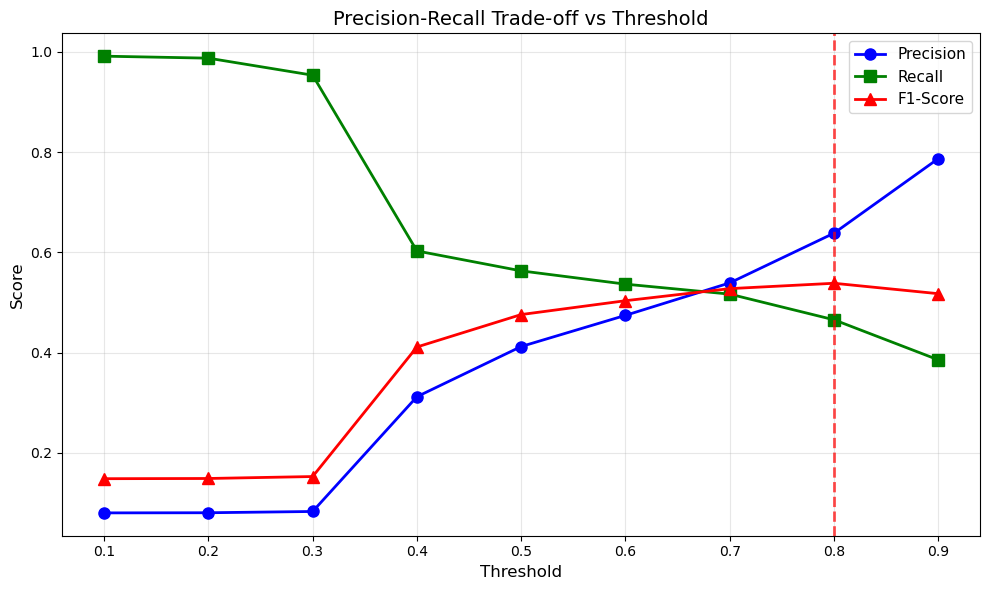

In [11]:

# FIND OPTIMAL THRESHOLD


thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for threshold in thresholds:
    y_pred_adj = (y_prob_nn > threshold).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred_adj, average='binary')
    results.append({
        'threshold': threshold, 
        'precision': p, 
        'recall': r, 
        'f1_score': f
    })

results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("THRESHOLD OPTIMIZATION RESULTS")
print("=" * 60)
print(results_df.to_string(index=False))

# Find best threshold
best = results_df.loc[results_df['f1_score'].idxmax()]
print(f"\n✅ BEST THRESHOLD: {best['threshold']}")
print(f"   Precision: {best['precision']:.4f}")
print(f"   Recall: {best['recall']:.4f}")
print(f"   F1-Score: {best['f1_score']:.4f}")

# Plot threshold vs metrics
plt.figure(figsize=(10, 6))
plt.plot(thresholds, results_df['precision'], 'b-o', label='Precision', linewidth=2, markersize=8)
plt.plot(thresholds, results_df['recall'], 'g-s', label='Recall', linewidth=2, markersize=8)
plt.plot(thresholds, results_df['f1_score'], 'r-^', label='F1-Score', linewidth=2, markersize=8)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision-Recall Trade-off vs Threshold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=best['threshold'], color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.tight_layout()
plt.show()

In [14]:

# SAVE THE BEST MODEL


import joblib

# Save neural network model
joblib.dump(nn_model, 'neural_network_fraud_model.pkl')
print("✅ Neural network model saved as 'neural_network_fraud_model.pkl'")

# Save the best threshold for future predictions
import json
with open('best_threshold.json', 'w') as f:
    json.dump({'threshold': float(best['threshold'])}, f)
print("✅ Best threshold saved as 'best_threshold.json'")

print("\n📁 Files saved successfully!")

✅ Neural network model saved as 'neural_network_fraud_model.pkl'
✅ Best threshold saved as 'best_threshold.json'

📁 Files saved successfully!


In [24]:
# Run this as a single cell to reset everything

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("RUNNING FULL PREPROCESSING")
print("=" * 50)

# Step 1: Load data
print("1. Loading data...")
transaction = pd.read_csv(r"C:\Users\Jeric\OneDrive\Documents\Big Data Fraud Detection\Big-Data-Fraud-Detection\Datasets\train_transaction.csv")
identity = pd.read_csv(r"C:\Users\Jeric\OneDrive\Documents\Big Data Fraud Detection\Big-Data-Fraud-Detection\Datasets\train_identity.csv")

# Step 2: Merge
print("2. Merging data...")
df = transaction.merge(identity, on='TransactionID', how='left')
print(f"   Shape: {df.shape}")

# Step 3: Drop high-missing columns
print("3. Dropping columns with >70% missing...")
threshold = len(df) * 0.7
df = df.dropna(thresh=threshold, axis=1)
print(f"   Shape after: {df.shape}")

# Step 4: Select top features by correlation
print("4. Selecting top correlated features...")
corr = df.corr(numeric_only=True)
corr_target = corr['isFraud'].abs().sort_values(ascending=False)
top_features = corr_target.head(20).index.tolist()
df = df[top_features]
print(f"   Features: {top_features[:5]}...")
print(f"   Shape: {df.shape}")

# Step 5: Encode categoricals
print("5. Encoding categorical variables...")
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Step 6: Split data
print("6. Splitting data...")
X = df.drop('isFraud', axis=1)
y = df['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"   Train: {X_train.shape}, Test: {X_test.shape}")

# Step 7: Handle missing values
print("7. Handling missing values...")
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

# Step 8: SMOTE
print("8. Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"   After SMOTE: {X_train_res.shape}")

print("\n" + "=" * 50)
print("✅ PREPROCESSING COMPLETE")
print("=" * 50)

# Now train all three models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

print("\n" + "=" * 50)
print("TRAINING MODELS")
print("=" * 50)

print("Training Logistic Regression...")
model1 = LogisticRegression(max_iter=1000, random_state=42)
model1.fit(X_train_res, y_train_res)

print("Training Random Forest...")
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train_res, y_train_res)

print("Training Neural Network...")
nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
nn_model.fit(X_train_res, y_train_res)

print("\n✅ All models trained successfully!")

# Evaluate
from sklearn.metrics import classification_report

print("\n" + "=" * 50)
print("EVALUATION")
print("=" * 50)

print("\nLogistic Regression:")
print(classification_report(y_test, model1.predict(X_test)))

print("\nRandom Forest:")
print(classification_report(y_test, model2.predict(X_test)))

print("\nNeural Network:")
y_pred_nn = nn_model.predict(X_test)
print(classification_report(y_test, y_pred_nn))

RUNNING FULL PREPROCESSING
1. Loading data...
2. Merging data...
   Shape: (590540, 434)
3. Dropping columns with >70% missing...
   Shape after: (590540, 202)
4. Selecting top correlated features...
   Features: ['isFraud', 'V45', 'V44', 'V86', 'V87']...
   Shape: (590540, 20)
5. Encoding categorical variables...
6. Splitting data...
   Train: (472432, 19), Test: (118108, 19)
7. Handling missing values...
8. Applying SMOTE...
   After SMOTE: (911804, 19)

✅ PREPROCESSING COMPLETE

TRAINING MODELS
Training Logistic Regression...
Training Random Forest...
Training Neural Network...

✅ All models trained successfully!

EVALUATION

Logistic Regression:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91    113975
           1       0.09      0.44      0.16      4133

    accuracy                           0.83    118108
   macro avg       0.54      0.64      0.53    118108
weighted avg       0.95      0.83      0.88    118108


Random Forest: